# Cutout Compilation for Kinematic Lensing

This notebook takes the reduced 2D grism and photometric images, and build cutout collections for each galaxy in the source catalog. The output cutouts will be directly used in `kltools` for KL measurement, therefore, we need to unify the data format and conventions in photometry and grism images, and also provide essential header information used by `kltools` for KL measurement. 


## 1. Compilation File Format

The compilation would includes 

### 1.1 Primary header
The primary header includes lots of information of the source galaxy and the configuration of this observation. Some of the header terms are
- `RA0`, `DEC0`: the coordinate of the object in direct imaging.
- `N_COADD`, `N_R`, `N_C`: number of the total exposures, exposure with grismR, and grismC
- `ID`, `RA`, `DEC`, `z_grism`, `SN_peak`, `fit_center_um`, etc.: The row correspond to this galaxy in the source redshift catalog
- `IMG1`, `NOISE1`, `PSF1`, `MASK1`, ... same for `2`, `3`, ...: The extension name the data, noise, PSF model, and mask (1=good, 0=discarded) of each cutout.
- `NEXTEN`: number of extensions
- `OBSNUM`: number of observations (or cutouts)

### 1.2 Broadband photometric image
Each bradband image includes at least one extensions: data. For analyse on real JWST data, there are three more extensions are needed: noise (standard deviation), PSF model, and mask. The each extension includes a header and a data array, but the most comprehensive header information is in the data extension, and other extensions only contain minimal information. 

The data extension header includes the below terms:
- `BUNIT`: surface brightness unit.
- regular header information inherited from JWST image mosaic, including WCS, observation time and configuration, etc.
- `PIXSCALE`: the pixel scale in arcsec per pixel
- `OBSINDEX`: the index of this observation in the compilation, starting from 1. Note that each suite of data, noise, PSF, and mask is counted as one observation
- `OBSTYPE`: observation type, `0` = photometric broadband image, `1` = 1D fiber spectra, `2` = 2D grism
- `PSFTYPE`: PSF modeling type. 
    - `data` = use the PSF extention for a model PSF array, then `PSF${OBSINDEX}` must be provided in the primary header. 
    - `airy_mean` = use the Airy PSF at the mean wavelength of this bandpass. 
    - `airy_fwhm` = use the Airy PSF with a specified FWHM in arcsec, then `PSFFWHM` must be provided in the header. 
    - `moffat` = use the Moffat model in GalSim, then `PSFBETA` and `PSFFWHM` must be provided. 
- `NOISETYP`: noise type (not used in real data)
- `ADDNOISE`: whether the data extension includes noise. This is always `True` for real data, but is `False` for noiseless mock data.                                                  
- `TEMP`: temperature factor used to weight the likelihood contribution of this observation. The likelihood is tempered by `log_like/TEMP` in the final posterior. Default is 1. 
The PSF extension header contains extra header information that is essential for PSF modeling:
- `WAVELEN`: the effective wavelength of this PSF model, in meter
- `DIFFLMT`: difraction limit PSF size, in arcsec
- `OVERSAMP`: oversampling factor from the native pixel size. For example, `OVERSAMP=4` means each pixel in the PSF extension is 25% of the native pixel in linear size scale. 
- `DET_SAMP`: detector sampling rate, till now same to `OVERSAMP`
- `PIXELSCL`: the pixel size in arcsec per super-sampled pixel
- `FOV`: field-of-view in arcsec, linear size
- `INSTRUME`, `FILTER`, `DET_NAME`, `APERNAME`, `MODULE`, `CHANNEL`, `PILIN`: some parameters used for generating the PSF model using `stpsf`

The data array of each extension in data, noise, PSF, and mask must be alligned properly in WCS. For brandband image, we only support the standard equatorial WCS, meaning +X = west, and +Y = north. 

### 1.3 Grism emission line
There could be multiple grism emission line cutouts. Each cutout would include data, noise, PSF, and mask, just like the broadband image. Most of the useful information is saved in the header of the data extension. Depending on the grism stacking method, there could be two sets of header conventions. 

If the grism cutout is stacked by the `simple` method, then the header includes
- `WAVE_1`: the wavelength in $\mu m$ of the center of the first pixel
- `D_WAVE`: wavelength dispersion in $\mu m$ per pixel
- `PIXSCALE`: the spatial pixel scale in arcsec per pixel
- `APERTURE`: linear cutout size
- `EMISSION`: name of the emission line
- `BUNIT`: surface brightness unit, should be `DN/s`
- `EMLFITSN`: preliminary estimate of the emission line SNR (1D spectrum)
- `DISPANG`: the mean dispersion angle in radians, CCW starting from +X. In the `simple` method, the dispersion angle is defined in detector frame, and should always be close to zero (i.e. dispersed along the X-axis)
- `DISPANGW`: the dispersion angle standard deviation among the stacked frames. Note that since the exact dispersion angle depends on the detector position of the emission line, each exposure may have slightly different dispersion angle even if the roll angle of the telescope is the same. `DISPANGW` measures the spread of the dispersion angle, and should be a tiny number. 
- `FRAME_PA`: the frame position angle (or roll angle) defined on the equatorial WCS frame, in radian. This measures the angle from the west direction to the +X direction of the cutout, CCW. For `simple`-based mosaic, the `FRAME_PA` is the actuall dispersion angle on the RA-DEC frame. 
- `CHIRAL`: charality of the spectrum, 1 for right-handed and -1 for left-handed. For the `simple` method, this should always be +1. 
- `OBSINDEX`: observation index
- `NEXPA`, `NEXPB`: number of exposures in mode A/B
- `OBSTYPE`: see brandband image header
- `BANDPASS`: file name containing the grism bandpass function, used by `kltools`. The bandpass has the unit of `(DN/s)/(phot/s/cm2/nm)`. Note that the bandpass file is the supportive file of `kltools` and generally locates in `kltools` folder. 
- `SEDBLKID`: for multi-line modeling, the full SED is break into several blocks, each block is centered around a specific emission line. The `SEDBLKID` (starting from 0) is the index of the SED block of this emission line cutout. 
- `RSPEC`: spectroscopic resolution power $R\equiv \frac{\lambda}{\delta\lambda}$ at $\lambda=1\mu m$, where $\delta\lambda$ is the wavelength dispersion per **resolving element**, which is two native pixels for Roman. Note that Roman has a almost constant $\delta\lambda$, therefore, $R$ is calibrated to the value at $\lambda=1\mu m$. 
- `OFFSET`: the offset in number of pixels that will bring the targeted emission line observed wavelength back to the center of the cutout. For example, is the target emission line is observed at 4 micron, then the offset $\Delta L$ is $$\Delta L=-\frac{\lambda_\mathrm{obs}}{1\, \mathrm{nm}}\times \frac{R}{500}$$
- `PSFTYPE`, `NOISETYP`, `ADDNOISE`, `TEMP`: see the photometry image cutout header. 

If the grism cutout is stacked by the `drizzle` method, then the header will not include `WAVE_1` and `D_WAVE`. `DISPANG` is the dispersion angle is defined on the WCS frame. The `FRAME_PA` should always be zero, since the drizzle cutout is always aligned to the equatorial WCS. `CHIRAL` is +1 for modeA-grismR, and -1 for all the other mode-pupil combinations. 

> Comment on `CHIRAL`: the fact that JWST NIRCam has two modes A and B and two grism pupils R and C makes grism spectra extraction a little bit more complex. There are two ways to build grism cutouts and compare to KL model prediction. The first scenario is (let's call it the simple scenario), take cutout on the extracted 2D spectra in ($\lambda$, $y$) coordinate, and compare to model. In this case, the cutout is not aligned to WCS. Depending on which pupil is used, $+\lambda$ could mean +X or +Y of the detector axis, and $+y$ could mean $+X$ or $+Y$ detector axis as well. Note that cosmic shear is defined in RA-DEC equatorial WCS coordinate. Therefore, we choose to rotate the 3D galaxy KL model (galaxy intensity profile and velociyt field) and align them to the $+\lambda$ direction, and then disperse along the $+x$ direction. However, the mapping of $+y$ direction is tricky: in the original Fengwu's grism pipeline, $+y$ is the detector $+Y$ direction when using grism R, and is $+X$ when using grism C. Some of those configurations can not be modeled as a rotation plus a +X dispersion, because rotation can not change the chirality of the spectra --- defined by the direction of $\vec{\lambda}\times\vec{y}$. For example, when the spectra is from module A grism C, the dispersion is along $+Y$, and we rotate the galaxy to align it to $+Y$ direction, then the $Y$-direction of this rotated galaxy would be along the $-X$ direction of the detector, in opposite direction of $+y$. Therefore, for the ease of modeling, when using simple coaddition, all the output grism cutouts are in `CHIRAL=+1` such that the data can be modeled as a KL model with rotation and +X dispersion. 
> For drizzle coaddition method, since the frame is already aligned to RA and DEC, we don't rotate the KL model, and directly do the dispersion on the RA-DEC equatorial frame, controled by the `DISPANG` parameter. The `CHIRAL` is the native value, and does not impact the KL fitting. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from astropy.table import Table
from astropy.table import join, vstack, unique
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D, NoOverlapError, NDData
import stpsf
import glob
from scipy.ndimage import median_filter, generic_filter
from astropy.stats import SigmaClip
from photutils.background import StdBackgroundRMS
import sep
import galsim as gs
import re
import os
from scipy.ndimage import binary_dilation
import warnings
warnings.filterwarnings("ignore", message="Keyword name.*FITS standard", module="astropy.io.fits.card")
warnings.filterwarnings("ignore", message="Card is too long, comment will be truncated.", module="astropy.io.fits.card")

def create_interloper_mask(image, bkg_std, threshold=1.5, margin_pixels=1,
                           gaussian_sigma=None, extra_images=None):
    """
    Build a boolean interloper mask using source detection + deblending.

    If extra_images provides at least one additional valid image (same shape,
    not all-zero / mostly-NaN), multi-band detection is used: each valid band
    is normalised by its own RMS and the per-pixel sum is used as the detection
    image, boosting sensitivity to faint interlopers.  Otherwise single-band
    SEP detection is used with aggressive deblending (deblend_nthresh=64,
    deblend_cont=0.001) to separate sources that merge at low thresholds.

    In both cases the source nearest the image centre is treated as the target;
    all other detections (modulo the margin_pixels dilation) are flagged as
    interlopers.

    Parameters
    ----------
    image : 2D array
        Primary science image.
    bkg_std : float
        Background RMS of the primary image; used as detection noise in
        single-band mode.
    threshold : float
        Detection threshold in units of the detection-image noise.
    margin_pixels : int
        Binary-dilation radius applied to the central source footprint before
        collecting labels that are kept (i.e. not flagged as interlopers).
    gaussian_sigma : float or None
        If set, apply a Gaussian pre-filter of this sigma (pixels) before
        source detection.
    extra_images : list of 2D array or None
        Additional images of the same spatial shape as `image`.  Each entry is
        tested for validity; images that are None, wrong-shaped, or have fewer
        than 10 % finite non-zero pixels are silently discarded.

    Returns
    -------
    interloper_mask : bool array, same shape as `image`
        True where interloper sources are detected.
    """

    def _is_valid(img):
        if img is None or np.asarray(img).shape != image.shape:
            return False
        arr = np.asarray(img)
        valid = np.isfinite(arr) & (arr != 0)
        return int(valid.sum()) >= int(0.1 * arr.size)

    # Gather all candidate bands; primary image is always included
    candidates = [image] + (list(extra_images) if extra_images is not None else [])
    valid_images = [np.asarray(img, dtype=np.float32) for img in candidates if _is_valid(img)]
    if not valid_images:
        valid_images = [np.asarray(image, dtype=np.float32)]
    n_valid = len(valid_images)

    # ── Build the detection image ──────────────────────────────────────────────
    if n_valid > 1:
        # Multi-band: normalise each valid band by its own RMS, then sum.
        # The summed image has per-pixel noise ≈ sqrt(n_valid).
        _sc  = SigmaClip(sigma=3.0)
        _rms = StdBackgroundRMS(_sc)
        normed = []
        for img in valid_images:
            try:
                rms = float(_rms.calc_background_rms(img))
                normed.append(img / rms if rms > 0 else img.copy())
            except Exception:
                normed.append(img.copy())
        detection_data = np.sum(normed, axis=0)
        det_err = float(np.sqrt(n_valid))
    else:
        # Single-band with aggressive deblending
        detection_data = valid_images[0].copy()
        det_err = bkg_std

    # ── Optional Gaussian pre-filter ──────────────────────────────────────────
    filter_kernel = None
    if gaussian_sigma is not None and gaussian_sigma > 0:
        kernel_size = 2 * int(4.0 * gaussian_sigma + 0.5) + 1
        kernel = gs.Gaussian(sigma=gaussian_sigma).drawImage(
            nx=kernel_size, ny=kernel_size, scale=1.
        ).array
        kernel /= np.sum(kernel)
        filter_kernel = kernel

    # ── Source extraction with deblending ──────────────────────────────────────
    try:
        objects, segmap = sep.extract(
            detection_data,
            thresh=threshold,
            err=det_err,
            segmentation_map=True,
            filter_kernel=filter_kernel,
            deblend_nthresh=64,
            deblend_cont=0.001,
        )
    except Exception as e:
        print(f"Warning: SEP source extraction failed with error: {e}")
        return np.zeros_like(image, dtype=bool)

    if (objects is None) or (len(objects) == 0):
        return np.zeros_like(image, dtype=bool)

    im_center_y, im_center_x = np.array(image.shape) / 2.0
    distances_sq = (objects['x'] - im_center_x)**2 + (objects['y'] - im_center_y)**2
    central_obj_index = np.argmin(distances_sq)
    central_label = central_obj_index + 1

    if len(objects) <= 1:
        return np.zeros_like(image, dtype=bool)

    central_source_mask = (segmap == central_label)
    if margin_pixels > 0:
        structure = np.ones((3, 3), dtype=bool)
        dilated_mask = binary_dilation(central_source_mask, structure=structure, iterations=margin_pixels)
    else:
        dilated_mask = central_source_mask
    labels_to_keep = np.unique(segmap[dilated_mask])
    is_source = (segmap != 0)
    is_kept_source = np.isin(segmap, labels_to_keep)
    interloper_mask = is_source & ~is_kept_source

    return interloper_mask

def correct_zero_noise(cutout):
    # correct pixels with zero noise to surounding median
    if not np.all(cutout.data > 0.0):
        for i in range(cutout.data.shape[0]):
            for j in range(cutout.data.shape[1]):
                if cutout.data[i,j] <= 0.0:
                    batch = cutout.data[i-3:i+4,j-3:j+4]
                    batch = batch[np.where(batch>0.0)[0]]
                    cutout.data[i,j] = np.median(batch)
    return cutout

def get_image_cutout(full_data, full_error, target_position, size, wcs):
    ''' Get a cutout of the image centered on the target position. '''
    try:
        img = Cutout2D(full_data, target_position, size=size, wcs=wcs)
        err = correct_zero_noise(Cutout2D(full_error, target_position, size=size, wcs=wcs))
    except NoOverlapError:
        print(f"Target at {target_position} is out of bounds for cutout size {size}.")
        img, err = None, None
    return img, err

def get_mean_PSF(filter_name, oversample=4, fov_arcsec=4):
    ''' Get the mean PSF for a given filter, oversampling factor, and field of view. '''
    nc = stpsf.NIRCam()
    nc.filter          = filter_name
    nc.pupil_mask      = None
    psf_model  = nc.calc_psf(
        oversample=oversample,
        fov_arcsec=fov_arcsec,
        normalize="last",
    )
    PSF_FITS = fits.ImageHDU(psf_model["OVERDIST"].data, name = filter_name.upper()+'PSF')
    for key in ["WAVELEN", "DIFFLMT", "OVERSAMP", "DET_SAMP", "PIXELSCL", "FOV", "INSTRUME", "FILTER", 
                "DET_NAME", "APERNAME", "MODULE", "CHANNEL", "PILIN"]:
        PSF_FITS.header[key] = psf_model["OVERDIST"].header[key]
    return PSF_FITS

def mask_hot_pixels(image, threshold=5.0, sigma_clip_sigma=3.0, kernel_size=3,
                    use_median=True, bkg_std=None):
    """
    Mask hot pixels in an image cutout.

    Parameters
    ----------
    image : np.ndarray
        2D array of the image data.
    threshold : float, optional
        Number of standard deviations above the local background to consider
        a pixel as hot. Default is 5.0.
    sigma_clip_sigma : float, optional
        Sigma value for sigma clipping (only used when bkg_std is None). Default 3.0.
    kernel_size : int, optional
        Size of the kernel for local comparison (must be odd). Default is 3.
    use_median : bool, optional
        If True use median filtering; if False use sigma clipping. Default True.
    bkg_std : float, optional
        Pre-computed background RMS. If None, it is estimated internally.

    Returns
    -------
    mask : np.ndarray
        Boolean mask where True indicates hot pixels (to be masked out).
    """
    if bkg_std is None:
        sigma_clip = SigmaClip(sigma=sigma_clip_sigma)
        bkgrms = StdBackgroundRMS(sigma_clip)
        bkg_std = float(bkgrms.calc_background_rms(image))
    bkgrms_value = bkg_std

    if use_median:
        median_filtered = median_filter(image, size=kernel_size)
        deviation = np.abs(image - median_filtered)
        mask = deviation > (threshold * bkgrms_value)
    else:
        def is_outlier(values):
            center_idx = len(values) // 2
            center_val = values[center_idx]
            neighbors = np.concatenate([values[:center_idx], values[center_idx+1:]])
            if len(neighbors) == 0:
                return 0
            median = np.median(neighbors)
            std = np.std(neighbors)
            if std == 0:
                std = bkgrms_value
            return 1 if (center_val - median) > threshold * std else 0
        mask = generic_filter(image, is_outlier, size=kernel_size, mode='constant', cval=0.0)
        mask = mask.astype(bool)

    return mask


def mask_hot_pixels_iterative(image, threshold=5.0, max_iterations=3, **kwargs):
    """
    Iteratively mask hot pixels until no more are found or max iterations reached.
    Any keyword arguments (including bkg_std) are forwarded to mask_hot_pixels().
    """
    mask = np.zeros_like(image, dtype=bool)

    for i in range(max_iterations):
        masked_image = np.copy(image)
        masked_image[mask] = np.nan
        new_mask = mask_hot_pixels(np.nan_to_num(masked_image, nan=0.0),
                                   threshold=threshold, **kwargs)
        new_hot_pixels = np.sum(new_mask & ~mask)
        if new_hot_pixels == 0:
            break
        mask = mask | new_mask

    return mask, i + 1

def build_mask(image, bkg_std=None, clip_sigma=3.0, interloper_threshold=3.0,
               hot_pixel_threshold=50.0, hot_pixel_maxiter=1, input_mask=None,
               extra_images=None, margin_pixels=1, gaussian_sigma=None):
    '''Build a mask for potential interlopers and hot pixels.

    Parameters
    ----------
    image : 2D array
        Input image data.
    bkg_std : float, optional
        Background RMS noise. If None, it is estimated internally from image
        using SigmaClip + StdBackgroundRMS. Pass a pre-computed value (e.g.
        from a larger-area cutout) for a more robust estimate.
    clip_sigma : float, optional
        Sigma for internal background RMS estimation (only used when
        bkg_std is None). Default 3.0.
    interloper_threshold, hot_pixel_threshold, hot_pixel_maxiter, input_mask
        Same as before.
    extra_images : list of 2D array or None
        Additional same-shape images forwarded to create_interloper_mask for
        multi-band interloper detection.  See create_interloper_mask for details.

    Returns
    -------
    mask : 2D float array
        Mask with 1 = good pixel, 0 = bad pixel.
    '''
    if bkg_std is None:
        sigma_clip = SigmaClip(sigma=clip_sigma)
        bkgrms = StdBackgroundRMS(sigma_clip)
        bkg_std = float(bkgrms.calc_background_rms(image))

    mask_interloper = create_interloper_mask(
        image, bkg_std, threshold=interloper_threshold,
        extra_images=extra_images, margin_pixels=margin_pixels, gaussian_sigma=gaussian_sigma
    )
    hotpix_mask, niters = mask_hot_pixels_iterative(
        image, threshold=hot_pixel_threshold, max_iterations=hot_pixel_maxiter,
        bkg_std=bkg_std
    )
    mask = 1.0 - (mask_interloper | hotpix_mask)
    if input_mask is not None:
        mask = np.minimum(mask, input_mask)

    return mask


def estimate_cutout_snr(image, bkg_std, detection_threshold=1.5, dilation_iters=2):
    '''Estimate the SNR of the central source in a 2D cutout via SEP segmentation.

    Parameters
    ----------
    image : 2D array
        Emission-line (continuum-subtracted) cutout.
    bkg_std : float
        Background RMS noise estimate.
    detection_threshold : float, optional
        Source detection threshold in units of bkg_std. Default 1.5.
    dilation_iters : int, optional
        Binary dilation iterations applied to the central segment before
        summing flux. Default 2.

    Returns
    -------
    snr : float
        Estimated SNR.  Returns np.nan if no source is detected.
    '''
    data = image.copy().astype(np.float64)
    try:
        objects, segmap = sep.extract(data, thresh=detection_threshold,
                                      err=bkg_std, segmentation_map=True)
    except Exception:
        return np.nan

    if objects is None or len(objects) == 0:
        return np.nan

    im_cy, im_cx = np.array(image.shape) / 2.0
    dist_sq = (objects['x'] - im_cx)**2 + (objects['y'] - im_cy)**2
    central_label = int(np.argmin(dist_sq)) + 1

    central_seg = (segmap == central_label)
    structure   = np.ones((3, 3), dtype=bool)
    dilated_seg = binary_dilation(central_seg, structure=structure, iterations=dilation_iters)

    n_pix = int(np.sum(dilated_seg))
    if n_pix == 0:
        return np.nan

    total_flux = float(np.sum(data[dilated_seg]))
    noise = bkg_std * np.sqrt(n_pix)
    return total_flux / noise


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


## 2. Per-Dataset Compilation

Let's first try to build cutouts per dataset (FRESCO GDS, FRESCO GSN, CONGRESS GDN)

In [2]:
dataset = "congress"
dataset_long = "CONGRESS PID3577"
field_long = "goods-n"
field_short = "GDN"
grism_band = "F356W"
image_band = "F444W"
catalog_tag = "gdn_congress"
blended_tag = "blended"

### Input file info: we are building compilation for the simple-coaddition of grism cutouts
extract_dir = f"/xdisk/timeifler/jiachuanxu/jwst/{dataset}/extract"
emline_cutout_fmt = f"emline_2d_{grism_band}_ID*_*_*coadd_simple.fits"
# load the source catalog
catalog_file = f"/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v2_{catalog_tag}_line_list_low-ground-z_Pa_Br_jades_dr5_{blended_tag}.fits"
catalog = Table.read(catalog_file)
# load F444W mosaic
image_mosaic = fits.open(f"/xdisk/timeifler/jiachuanxu/jwst/jades/mosaics/hlsp_jades_jwst_nircam_{field_long}_{image_band.lower()}_v5.0_drz.fits")
mosaic_wcs = WCS(image_mosaic[1].header)

# image cutout size
image_cutout_size = (62 * image_mosaic[1].header["PIXAR_A2"]**0.5) * u.arcsec

# mean PSF in photometric image band
mean_psf = get_mean_PSF(image_band, oversample=4, fov_arcsec=4)

# transmission bandpass in grism band
transmission_bandpass = f"../data/Bandpass/JWST/NIRCam_WFSS_{grism_band}_mod%s_grism%s_sensitivity.dat"

# output dir
output_dir = f"/xdisk/timeifler/jiachuanxu/jwst/{dataset}/data_compile"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

overwrite = True

# Ratio of the background estimation region to the analysis cutout size.
# A larger cutout gives a more robust background RMS estimate.
BKG_CUTOUT_FACTOR = 5

# Short-wavelength mosaics for pseudo-RGB diagnostic (R=F444W, G=F200W, B=F115W)
_mosaic_base = "/xdisk/timeifler/jiachuanxu/jwst/jades/mosaics"
try:
    image_mosaic_f200w = fits.open(f"{_mosaic_base}/hlsp_jades_jwst_nircam_{field_long}_f200w_v5.0_drz.fits")
    wcs_f200w = WCS(image_mosaic_f200w[1].header)
    print("F200W mosaic loaded.")
except FileNotFoundError:
    image_mosaic_f200w = None
    wcs_f200w = None
    print("Warning: F200W mosaic not found; RGB panel will be blank.")

try:
    image_mosaic_f115w = fits.open(f"{_mosaic_base}/hlsp_jades_jwst_nircam_{field_long}_f115w_v5.0_drz.fits")
    wcs_f115w = WCS(image_mosaic_f115w[1].header)
    print("F115W mosaic loaded.")
except FileNotFoundError:
    image_mosaic_f115w = None
    wcs_f115w = None
    print("Warning: F115W mosaic not found; RGB panel will be blank.")


F200W mosaic loaded.
F115W mosaic loaded.


In [ ]:
### Merge the two GOODS-N catalogs (CONGRESS and FRESCO) into a single catalog, keeping unique sources based on the ID column. 
catalog_file1 = f"/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v2_gdn_congress_line_list_low-ground-z_Pa_Br_jades_dr5_blended.fits"
catalog1 = Table.read(catalog_file1)

catalog_file2 = f"/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v2_gdn_fresco_line_list_low-ground-z_Pa_Br_jades_dr5_blended.fits"
catalog2 = Table.read(catalog_file2)

# merge the two catalog based on the ID column
merged_catalog = unique(vstack([catalog1, catalog2]), keys='ID', keep='first')

print(f"Merged catalog contains {len(merged_catalog)} unique sources from both catalogs.")
print(f"Number of sources from catalog1: {len(catalog1)}")
print(f"Number of sources from catalog2: {len(catalog2)}")

# merged_catalog.write(f"/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v2_gdn_line_list_low-ground-z_Pa_Br_jades_dr5_blended.fits", overwrite=True)

Merged catalog contains 521 unique sources from both catalogs.
Number of sources from catalog1: 336
Number of sources from catalog2: 251


In [9]:
for i in range(len(catalog)):
    objid = catalog["ID"][i]
    cutout_files = sorted(glob.glob(f"{extract_dir}/emline_2d_{grism_band}_ID{objid}_*_*coadd_simple.fits"))
    obj_pos = SkyCoord(catalog["RA"][i], catalog["DEC"][i], unit="deg")

    output_filename = f"{output_dir}/data_compile_{field_short}_ID{objid}.fits"
    if os.path.exists(output_filename) and (not overwrite):
        print(f"Skipping object ID {objid}: output already exists.")
        continue

    if len(cutout_files) == 0:
        print(f"Skipping object ID {objid}: no grism cutout files found.")
        continue

    ### 1. Photometric Image Cutout
    image, error = get_image_cutout(
        image_mosaic["SCI"].data, image_mosaic["ERR"].data,
        obj_pos, image_cutout_size, mosaic_wcs
    )
    if (image is None) or (error is None) or (np.allclose(image.data, 0.0)):
        print(f"Skipping object ID {objid}: photometric cutout failed.")
        continue

    # Estimate background RMS from a BKG_CUTOUT_FACTOR-times larger cutout
    large_img, _ = get_image_cutout(
        image_mosaic["SCI"].data, image_mosaic["ERR"].data,
        obj_pos, image_cutout_size * BKG_CUTOUT_FACTOR, mosaic_wcs
    )
    _sc = SigmaClip(sigma=3.0)
    _bkgrms_est = StdBackgroundRMS(_sc)
    if large_img is not None and not np.allclose(large_img.data, 0.0):
        photo_bkg_std = float(_bkgrms_est.calc_background_rms(large_img.data))
    else:
        photo_bkg_std = float(_bkgrms_est.calc_background_rms(image.data))

    # Default mask: pixels with positive, finite noise
    photo_default_mask = ((error.data > 0) & np.isfinite(error.data)).astype(float)

    # Collect F200W / F115W cutouts for multi-band interloper detection.
    # Use plain Cutout2D (no error correction) to avoid side-effects on mosaic data.
    _extra_photo = []
    for _em, _ew in [(image_mosaic_f200w, wcs_f200w), (image_mosaic_f115w, wcs_f115w)]:
        if _em is not None:
            try:
                _ec = Cutout2D(_em[1].data, obj_pos, size=image_cutout_size, wcs=_ew)
                _extra_photo.append(_ec.data.astype(float))
            except Exception:
                pass

    photo_mask = build_mask(image.data, bkg_std=photo_bkg_std, clip_sigma=3.0,
                            interloper_threshold=3.0, hot_pixel_threshold=50.0,
                            hot_pixel_maxiter=1, input_mask=photo_default_mask,
                            margin_pixels=0, # dont dilate the central source mask for high SNR image
                            extra_images=_extra_photo if _extra_photo else None)

    ### 2. Grism Image Cutouts
    grism_extensions = []
    emline_to_sedblkid = {}
    sedblkid_counter = 0
    total_N_R = 0
    total_N_C = 0

    for fn in cutout_files:
        match = re.search(r'_(AR|BR|AC|BC)coadd_', fn)
        if match is None:
            print(f"  Warning: cannot parse module/pupil from {fn}, skipping.")
            continue
        MP_flag = match.group(1)
        module  = MP_flag[0]
        pupil   = MP_flag[1]
        bandpass_file = transmission_bandpass % (module, pupil)

        with fits.open(fn) as grism_cutout:
            prim_hdr   = grism_cutout[0].header
            line2d_hdr = grism_cutout["LINE2D"].header
            n_coadd    = int(prim_hdr.get("N_COADD", 1))

            linewave_um = float(prim_hdr.get(
                "LINEWAVE",
                float(line2d_hdr["WAVE_1"]) + (line2d_hdr["NAXIS2"]-1.0)/2.0 * float(line2d_hdr["D_WAVE"])
            ))

            if pupil == 'R':
                total_N_R += n_coadd
            else:
                total_N_C += n_coadd

            emline_name = line2d_hdr["EMISSION"].strip()
            if emline_name not in emline_to_sedblkid:
                emline_to_sedblkid[emline_name] = sedblkid_counter
                sedblkid_counter += 1
            sedblkid = emline_to_sedblkid[emline_name]

            d_wave = float(line2d_hdr["D_WAVE"])
            rspec  = 1.0 / (2.0 * d_wave)
            offset = -(linewave_um * 1000.0) * (rspec / 500.0)

            ext_data  = f"{emline_name}_{MP_flag}"
            ext_noise = f"{emline_name}_{MP_flag}N"
            ext_psf   = f"{emline_name}_{MP_flag}P"
            ext_mask  = f"{emline_name}_{MP_flag}M"

            # --- Grism data HDU (from LINE2D) ---
            data_hdu = grism_cutout["LINE2D"].copy()
            data_hdu.data = data_hdu.data.astype(np.float32)
            data_hdu.header["EXTNAME"]  = ext_data
            if module == 'A':
                data_hdu.header["NEXPA"] = n_coadd
            else:
                data_hdu.header["NEXPB"] = n_coadd
            data_hdu.header["INSTNAME"] = "JWST/NIRCam"
            data_hdu.header["DATASET"] = dataset_long
            data_hdu.header["GRSMBAND"] = grism_band
            data_hdu.header["OBSTYPE"]  = 2
            data_hdu.header["BANDPASS"] = bandpass_file
            data_hdu.header["SEDBLKID"] = sedblkid
            data_hdu.header["RSPEC"]    = rspec
            data_hdu.header["PSFTYPE"]  = "data"
            data_hdu.header["OFFSET"]   = offset
            data_hdu.header["NOISETYP"] = "ccd"
            data_hdu.header["ADDNOISE"] = True
            data_hdu.header["TEMP"]     = 1.0

            # --- Grism noise HDU (from WHT2D) ---
            noise_hdu = grism_cutout["WHT2D"].copy()
            noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))
            noise_hdu.header["EXTNAME"]  = ext_noise
            noise_hdu.header["INSTNAME"] = "JWST/NIRCam"

            # Default mask: pixels with positive, finite noise
            grism_default_mask = ((noise_hdu.data > 0) & np.isfinite(noise_hdu.data)).astype(float)

            # Estimate background RMS from the grism LINE2D data (sigma-clipping;
            # no larger grism region is readily available from the extracted files)
            _sc_g = SigmaClip(sigma=3.0)
            _bkg_g = StdBackgroundRMS(_sc_g)
            grism_bkg_std = float(_bkg_g.calc_background_rms(data_hdu.data))

            # Estimate direct SNR from the emission-line cutout
            grism_snr = estimate_cutout_snr(data_hdu.data, grism_bkg_std)
            data_hdu.header["SXEMLSNR"] = (
                float(grism_snr) if np.isfinite(grism_snr) else -1.0
            )

            # --- Grism PSF HDU (from PSF2D) ---
            psf_hdu = grism_cutout["PSF2D"].copy()
            psf_hdu.data = psf_hdu.data.astype(np.float32)
            psf_hdu.header["EXTNAME"]  = ext_psf
            psf_hdu.header["INSTRUME"] = "NIRCam"
            psf_hdu.header["APERNAME"] = f"NRC{module}5_FULL"
            psf_hdu.header["INSTNAME"] = "JWST/NIRCam"
            # ad hoc correction: OVERSAMP and PIXELSCL were wrong in the source files
            psf_hdu.header["OVERSAMP"] = 4
            psf_hdu.header["PIXELSCL"] = 0.0629 / 4.0

            # --- Grism mask HDU (single-band; no useful ancillary bands at grism resolution) ---
            grism_mask = build_mask(data_hdu.data, bkg_std=grism_bkg_std, clip_sigma=3.0,
                                    interloper_threshold=3.0, hot_pixel_threshold=50.0,
                                    margin_pixels=1, # do dilate the central source mask for low SNR image
                                    hot_pixel_maxiter=1, input_mask=grism_default_mask)
            mask_hdu = fits.ImageHDU(grism_mask.astype(np.float32), name=ext_mask)
            mask_hdu.header["PIXSCALE"] = line2d_hdr["PIXSCALE"]
            mask_hdu.header["GOODVAL"]  = 1
            mask_hdu.header["INSTNAME"] = "JWST/NIRCam"

            grism_extensions.append((data_hdu, noise_hdu, psf_hdu, mask_hdu))

    if len(grism_extensions) == 0:
        print(f"Skipping object ID {objid}: no valid grism extensions built.")
        continue

    ### 3. Assign OBSINDEX  (grism obs: 0..N-1, photometric obs: N)
    for obs_idx, (data_hdu, noise_hdu, psf_hdu, mask_hdu) in enumerate(grism_extensions):
        data_hdu.header["OBSINDEX"]  = obs_idx
        noise_hdu.header["OBSINDEX"] = obs_idx
        psf_hdu.header["OBSINDEX"]   = obs_idx
        mask_hdu.header["OBSINDEX"]  = obs_idx

    photo_obs_idx  = len(grism_extensions)
    pixscale_photo = float(image_mosaic[1].header["PIXAR_A2"]) ** 0.5

    # --- Photometric image HDU ---
    photo_img_hdu = fits.ImageHDU(image.data.astype(np.float32), name="F444WIMG")
    photo_img_hdu.header.update(image.wcs.to_header())
    for key in ["BUNIT", "PIXAR_SR", "PIXAR_A2",
                "DATE-BEG", "MJD-BEG", "DATE-AVG", "MJD-AVG", "DATE-END", "MJD-END",
                "XPOSURE", "TELAPSE", "OBSGEO-X", "OBSGEO-Y", "OBSGEO-Z",
                "RADESYS", "VELOSYS", "MJDREF"]:
        if key in image_mosaic[1].header:
            photo_img_hdu.header[key] = image_mosaic[1].header[key]
    photo_img_hdu.header["PIXSCALE"] = pixscale_photo
    photo_img_hdu.header["OBSINDEX"] = photo_obs_idx
    photo_img_hdu.header["INSTNAME"] = "JWST/NIRCam"
    photo_img_hdu.header["OBSTYPE"]  = 0
    photo_img_hdu.header["PSFTYPE"]  = "data"
    photo_img_hdu.header["NOISETYP"] = "ccd"
    photo_img_hdu.header["ADDNOISE"] = True
    photo_img_hdu.header["TEMP"]     = 1.0

    # --- Photometric error HDU ---
    photo_err_hdu = fits.ImageHDU(error.data.astype(np.float32), name="F444WERR")
    photo_err_hdu.header["BUNIT"]    = image_mosaic[1].header.get("BUNIT", "MJy/sr")
    photo_err_hdu.header["OBSINDEX"] = photo_obs_idx
    photo_err_hdu.header["INSTNAME"] = "JWST/NIRCam"

    # --- Photometric PSF HDU ---
    photo_psf_hdu = mean_psf.copy()
    photo_psf_hdu.header["EXTNAME"]  = "F444WPSF"
    photo_psf_hdu.header["OBSINDEX"] = photo_obs_idx
    photo_psf_hdu.header["INSTNAME"] = "JWST/NIRCam"

    # --- Photometric mask HDU ---
    photo_mask_hdu = fits.ImageHDU(photo_mask.astype(np.float64), name="F444WMSK")
    photo_mask_hdu.header["PIXSCALE"] = pixscale_photo
    photo_mask_hdu.header["GOODVAL"]  = 1
    photo_mask_hdu.header["OBSINDEX"] = photo_obs_idx
    photo_mask_hdu.header["INSTNAME"] = "JWST/NIRCam"

    ### 4. Build Primary Header
    primary_hdu = fits.PrimaryHDU()
    phdr = primary_hdu.header

    phdr["RA0"]      = (float(catalog["RA"][i]),  "Reference position RA in direct image")
    phdr["DEC0"]     = (float(catalog["DEC"][i]), "Reference position DEC in direct image")
    phdr["N_COADD"]  = (total_N_R + total_N_C,    "Total coadded grism frames")
    phdr["N_R"]      = (total_N_R,                 "Number of grism-R frames")
    phdr["N_C"]      = (total_N_C,                 "Number of grism-C frames")
    phdr["FILTER"]   = ("F444W",                   "Photometric filter")
    phdr["COMMENTS"] = "Below are columns from the input source catalog:"

    for col in catalog.colnames:
        val = catalog[col][i]
        if hasattr(val, 'item'):
            val = val.item()
        if isinstance(val, (bytes, np.bytes_)):
            val = val.decode('utf-8').strip()
        try:
            phdr[col] = val
        except Exception:
            phdr[col] = str(val)

    obsnum = len(grism_extensions) + 1
    phdr["NEXTEN"] = (4,       "Extensions per observation: data, noise, PSF, mask")
    phdr["OBSNUM"] = (obsnum,  "Total number of observations")

    for obs_idx, (data_hdu, noise_hdu, psf_hdu, mask_hdu) in enumerate(grism_extensions):
        n = obs_idx + 1
        phdr[f"IMG{n}"]   = data_hdu.header["EXTNAME"]
        phdr[f"NOISE{n}"] = noise_hdu.header["EXTNAME"]
        phdr[f"PSF{n}"]   = psf_hdu.header["EXTNAME"]
        phdr[f"MASK{n}"]  = mask_hdu.header["EXTNAME"]

    n_photo = len(grism_extensions) + 1
    phdr[f"IMG{n_photo}"]   = "F444WIMG"
    phdr[f"NOISE{n_photo}"] = "F444WERR"
    phdr[f"PSF{n_photo}"]   = "F444WPSF"
    phdr[f"MASK{n_photo}"]  = "F444WMSK"

    ### 5. Assemble HDUList and write output
    hdul = fits.HDUList([primary_hdu])
    for data_hdu, noise_hdu, psf_hdu, mask_hdu in grism_extensions:
        hdul.append(data_hdu)
        hdul.append(noise_hdu)
        hdul.append(psf_hdu)
        hdul.append(mask_hdu)
    hdul.append(photo_img_hdu)
    hdul.append(photo_err_hdu)
    hdul.append(photo_psf_hdu)
    hdul.append(photo_mask_hdu)

    hdul.writeto(output_filename, overwrite=overwrite)
    print(f"Saved: {output_filename}")


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1000898.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1002943.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1003930.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1005809.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1009340.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1017054.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1017392.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1023128.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1024409.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1024494.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compil

/tmp/ipykernel_1449529/2487365931.py:126: RuntimeWarning: divide by zero encountered in divide
  noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1029341.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1029510.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1029619.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1029659.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1029937.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030028.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030135.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030224.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030351.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030388.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compil

/tmp/ipykernel_1449529/2487365931.py:126: RuntimeWarning: divide by zero encountered in divide
  noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030764.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030770.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030816.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030857.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1030884.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1031070.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1031120.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1031543.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1031595.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1031718.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compil

...

Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093191.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093207.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093208.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093222.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093230.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093271.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093286.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093353.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093401.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1093421.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compil

/tmp/ipykernel_1449529/2487365931.py:126: RuntimeWarning: divide by zero encountered in divide
  noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1094876.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1094968.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1094982.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095071.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095094.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095167.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095207.fits


/tmp/ipykernel_1449529/2487365931.py:126: RuntimeWarning: divide by zero encountered in divide
  noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095433.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095561.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095588.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095595.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095603.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095636.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095659.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095695.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095703.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1095720.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compil

In [10]:
### Sanity check: diagnostic stamp plots for each compiled output file
from scipy.ndimage import rotate as ndimage_rotate
from scipy.ndimage import zoom   as ndimage_zoom
from astropy.visualization import ZScaleInterval
from mpl_toolkits.axes_grid1 import make_axes_locatable

STAMP_HALF = 0.975   # arcsec — half of the 1.95 arcsec stamp
COL_TITLES = ["RGB (F444/200/115)", "BB (rotated)", "BB (masked)",
               "Grism data", "Grism (masked)", "Grism noise", "Grism PSF"]

diag_dir = f"/xdisk/timeifler/jiachuanxu/jwst/{dataset}/grism_cal/data_compile_short_stamp"
os.makedirs(diag_dir, exist_ok=True)

compile_files = sorted(glob.glob(f"{output_dir}/data_compile_{field_short}_ID*.fits"))
print(f"Found {len(compile_files)} compilation files.")

zscale = ZScaleInterval()

def safe_zscale(arr):
    finite = arr[np.isfinite(arr)]
    if len(finite) < 10:
        return float(np.nanmin(arr)), float(np.nanmax(arr))
    return zscale.get_limits(finite)

def make_extent(ny, nx, pixscale):
    return [-(nx / 2.0) * pixscale,  (nx / 2.0) * pixscale,
            -(ny / 2.0) * pixscale,  (ny / 2.0) * pixscale]

def pct_stretch(arr, lo_pct=0.5, hi_pct=99.5):
    finite = arr[np.isfinite(arr)]
    if len(finite) == 0:
        return np.zeros_like(arr)
    vmin = np.percentile(finite, lo_pct)
    vmax = np.percentile(finite, hi_pct)
    return np.clip((arr - vmin) / max(vmax - vmin, 1e-30), 0.0, 1.0)

def make_rgb(r, g, b):
    """Per-channel percentile stretch → (ny, nx, 3) float array."""
    def resize(arr, target):
        if arr.shape == target:
            return arr
        return ndimage_zoom(arr, (target[0]/arr.shape[0], target[1]/arr.shape[1]), order=1)
    r = pct_stretch(r)
    g = pct_stretch(resize(g, r.shape))
    b = pct_stretch(resize(b, r.shape))
    return np.stack([r, g, b], axis=-1)

def add_colorbar(fig, ax, im):
    """Attach a thin colorbar to the immediate right of ax using make_axes_locatable."""
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.03)
    cb = fig.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=5)
    # Limit the number of ticks to avoid crowding
    cb.locator = plt.MaxNLocator(nbins=3)
    cb.update_ticks()
    return cb

for compile_file in compile_files:
    with fits.open(compile_file) as hdul:
        phdr   = hdul[0].header
        objid  = phdr.get("ID", os.path.basename(compile_file))
        obsnum = int(phdr.get("OBSNUM", 1))

        # Classify observations by OBSTYPE
        grism_obs_list = []
        photo_obs_n    = None
        for n in range(1, obsnum + 1):
            img_name = phdr.get(f"IMG{n}", "")
            if img_name and img_name in hdul:
                obstype = hdul[img_name].header.get("OBSTYPE", -1)
                if obstype == 2:
                    grism_obs_list.append(n)
                elif obstype == 0:
                    photo_obs_n = n

        if not grism_obs_list or photo_obs_n is None:
            print(f"  Skipping ID {objid}: missing grism or photo obs.")
            continue

        # ── Photometric data ───────────────────────────────────────────────────
        photo_img_hdu  = hdul[phdr[f"IMG{photo_obs_n}"]]
        photo_mask_hdu = hdul[phdr[f"MASK{photo_obs_n}"]]
        photo_img_arr  = photo_img_hdu.data.astype(float)
        photo_mask_arr = photo_mask_hdu.data.astype(float)
        photo_px       = float(photo_img_hdu.header.get("PIXSCALE", 0.03))
        photo_ny, photo_nx = photo_img_arr.shape
        photo_extent   = make_extent(photo_ny, photo_nx, photo_px)

        # F200W / F115W cutouts for pseudo-RGB
        ra0  = float(phdr.get("RA0",  phdr.get("RA",  0.0)))
        dec0 = float(phdr.get("DEC0", phdr.get("DEC", 0.0)))
        obj_pos_diag   = SkyCoord(ra0, dec0, unit="deg")
        rgb_cutout_size = (photo_nx * photo_px) * u.arcsec

        def _get_rgb_chan(mosaic, wcs_obj):
            if mosaic is None:
                return None
            c, _ = get_image_cutout(mosaic[1].data, mosaic[2].data,
                                    obj_pos_diag, rgb_cutout_size, wcs_obj)
            return None if c is None else c.data.astype(float)

        arr_f200w = _get_rgb_chan(image_mosaic_f200w, wcs_f200w)
        arr_f115w = _get_rgb_chan(image_mosaic_f115w, wcs_f115w)

        # ── Figure layout (7 columns) ──────────────────────────────────────────
        n_rows = len(grism_obs_list)
        fig, axes = plt.subplots(n_rows, 7,
                                 figsize=(7 * 2.6, n_rows * 2.8),
                                 squeeze=False)
        for j, t in enumerate(COL_TITLES):
            axes[0, j].set_title(t, fontsize=8)

        # ── One row per grism observation ──────────────────────────────────────
        for row_idx, n in enumerate(grism_obs_list):
            grism_data_name  = phdr[f"IMG{n}"]
            grism_noise_name = phdr[f"NOISE{n}"]
            grism_psf_name   = phdr[f"PSF{n}"]
            grism_mask_name  = phdr.get(f"MASK{n}", None)

            ghdr   = hdul[grism_data_name].header
            gdata  = hdul[grism_data_name].data.astype(float)
            gnoise = hdul[grism_noise_name].data.astype(float)
            gpsf   = hdul[grism_psf_name].data.astype(float)
            gmask  = (hdul[grism_mask_name].data.astype(float)
                      if grism_mask_name and grism_mask_name in hdul
                      else np.ones_like(gdata))

            frame_pa       = float(ghdr.get("FRAME_PA", 0.0))
            grism_px       = float(ghdr.get("PIXSCALE", 0.0629))
            grism_ny, grism_nx = gdata.shape
            grism_extent   = make_extent(grism_ny, grism_nx, grism_px)

            psf_px         = float(hdul[grism_psf_name].header.get("PIXELSCL", grism_px / 4.0))
            psf_ny, psf_nx = gpsf.shape
            psf_extent     = make_extent(psf_ny, psf_nx, psf_px)

            frame_pa_deg    = np.degrees(frame_pa)
            ### Note: the ndimage_rotate CW for angle > 0 !!!! 
            bb_rot          = ndimage_rotate(photo_img_arr,  frame_pa_deg, reshape=False, order=3)
            bbmask_rot      = ndimage_rotate(photo_mask_arr, frame_pa_deg, reshape=False, order=0)

            g_chan = (ndimage_rotate(arr_f200w, frame_pa_deg, reshape=False, order=3)
                      if arr_f200w is not None else np.zeros_like(bb_rot))
            b_chan = (ndimage_rotate(arr_f115w, frame_pa_deg, reshape=False, order=3)
                      if arr_f115w is not None else np.zeros_like(bb_rot))
            rgb_img = make_rgb(bb_rot, g_chan, b_chan)

            bb_rot_masked   = bb_rot.copy();  bb_rot_masked[bbmask_rot < 0.5] = np.nan
            gdata_masked    = gdata.copy();   gdata_masked[gmask < 0.5]       = np.nan

            vbb0, vbb1   = safe_zscale(bb_rot)
            vg0,  vg1    = safe_zscale(gdata)
            vgn0, vgn1   = safe_zscale(gnoise)
            vgp0, vgp1   = safe_zscale(gpsf)

            kw  = dict(origin='lower', aspect='equal', interpolation='nearest')
            row = axes[row_idx]

            # ── Plot each panel and attach colorbar ────────────────────────────
            im0 = row[0].imshow(rgb_img,       extent=photo_extent,  **kw)
            # no colorbar for the RGB composite

            im1 = row[1].imshow(bb_rot,        extent=photo_extent,  cmap='gray_r', vmin=vbb0, vmax=vbb1, **kw)
            add_colorbar(fig, row[1], im1)

            im2 = row[2].imshow(bb_rot_masked, extent=photo_extent,  cmap='gray_r', vmin=vbb0, vmax=vbb1, **kw)
            add_colorbar(fig, row[2], im2)

            im3 = row[3].imshow(gdata,         extent=grism_extent,  cmap='gray_r', vmin=vg0,  vmax=vg1,  **kw)
            add_colorbar(fig, row[3], im3)

            im4 = row[4].imshow(gdata_masked,  extent=grism_extent,  cmap='gray_r', vmin=vg0,  vmax=vg1,  **kw)
            add_colorbar(fig, row[4], im4)

            im5 = row[5].imshow(gnoise,        extent=grism_extent,  cmap='viridis',vmin=vgn0, vmax=vgn1, **kw)
            add_colorbar(fig, row[5], im5)

            im6 = row[6].imshow(gpsf,          extent=psf_extent,    cmap='viridis',vmin=vgp0, vmax=vgp1, **kw)
            add_colorbar(fig, row[6], im6)

            # Annotate SXEMLSNR on the grism data panel (col 3)
            sxemlsnr     = ghdr.get("SXEMLSNR", np.nan)
            sxemlsnr_val = float(sxemlsnr)
            sxemlsnr_str = f"SrcEx SNR={sxemlsnr_val:.1f}" if np.isfinite(sxemlsnr_val) else "SNR=N/A"
            row[3].text(0.05, 0.05, sxemlsnr_str,
                        transform=row[3].transAxes, fontsize=12, color='yellow',
                        va='bottom', ha='left',
                        bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

            # Constrain all panels to 1.95 × 1.95 arcsec stamp
            for ax in row:
                ax.set_xlim(-STAMP_HALF, STAMP_HALF)
                ax.set_ylim(-STAMP_HALF, STAMP_HALF)
                ax.tick_params(labelsize=6)
                ax.set_xlabel("arcsec", fontsize=7)

            row[0].set_ylabel(f"{grism_data_name}\nPA={frame_pa_deg:.1f}°", fontsize=7)

        # ── Figure title ────────────────────────────────────────────────────────
        try:
            z_val = float(phdr.get("Z_GRISM", phdr.get("Z_SPEC", 0.0)))
            z_str = f"z={z_val:.4f}"
        except (TypeError, ValueError):
            z_str = ""
        try:
            fit_snr = float(phdr.get("FIT_LINE_SN", 0.0))
            snr_str = f"fit_SNR={fit_snr:.1f}" if fit_snr > 0 else ""
        except (TypeError, ValueError):
            snr_str = ""

        fig.suptitle(f"GDS ID {objid}  {z_str}  {snr_str}", fontsize=10)
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        save_path = f"{diag_dir}/diag_{field_short}_ID{objid}.png"
        fig.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {save_path}")


Found 336 compilation files.
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1000898.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1002943.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1003930.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1005809.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1009340.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1017054.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1017392.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1023128.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1024409.png
Saved: /

/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1084476.png


/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1084725.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1084800.png


...

Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1094740.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1094755.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1094842.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1094876.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1094968.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1094982.png


/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095071.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095094.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095167.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095207.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095433.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095561.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095588.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095595.png


/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095603.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095636.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095659.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095695.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095703.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095720.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095815.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095904.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress/grism_cal/data_compile_short_stamp/diag_GDN_ID1095927.png
Saved: /xdisk/timeifler/jiachuanxu/jw

## 3. Per-field Compilation

Since CONGRESS and FRESCO GDN share many common objects, we need to build joint compilation for objects in the GDN field. 

In [11]:
from collections import Counter
import astropy.table as table

blended_tag = "blended"
field_short = "GDN"

# ── Extract directories (one per dataset) ─────────────────────────────────────
extract_dir_congress = "/xdisk/timeifler/jiachuanxu/jwst/congress/extract"
extract_dir_fresco   = "/xdisk/timeifler/jiachuanxu/jwst/fresco_gdn/extract"

# Bandpass format strings per dataset (mod and grism filled in per file)
bandpass_fmt_congress = "../data/Bandpass/JWST/NIRCam_WFSS_F356W_mod%s_grism%s_sensitivity.dat"
bandpass_fmt_fresco   = "../data/Bandpass/JWST/NIRCam_WFSS_F444W_mod%s_grism%s_sensitivity.dat"

# ── Merged catalog: union of all unique galaxies in GDN from both programs ────
catalog_congress = Table.read(f"/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v2_gdn_congress_line_list_low-ground-z_Pa_Br_jades_dr5_{blended_tag}.fits")
catalog_fresco   = Table.read(f"/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog/v2_gdn_fresco_line_list_low-ground-z_Pa_Br_jades_dr5_{blended_tag}.fits")
catalog_merged   = table.unique(table.vstack([catalog_congress, catalog_fresco], join_type="outer"), keys="ID", keep='first')
print(f"CONGRESS: {len(catalog_congress)} objects, FRESCO GDN: {len(catalog_fresco)} objects")
print(f"Merged catalog: {len(catalog_merged)} unique IDs.")

# ── F444W photometric mosaic (shared by both programs) ────────────────────────
image_mosaic = fits.open("/xdisk/timeifler/jiachuanxu/jwst/jades/mosaics/hlsp_jades_jwst_nircam_goods-n_f444w_v5.0_drz.fits")
mosaic_wcs   = WCS(image_mosaic[1].header)

image_cutout_size = (62 * image_mosaic[1].header["PIXAR_A2"]**0.5) * u.arcsec

# F444W PSF (used for the photometric extension)
mean_psf = get_mean_PSF("F444W", oversample=4, fov_arcsec=4)

# ── Output directory ───────────────────────────────────────────────────────────
output_dir = "/xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile"
os.makedirs(output_dir, exist_ok=True)

overwrite = True
BKG_CUTOUT_FACTOR = 5

# ── Ancillary short-wavelength mosaics for pseudo-RGB diagnostic ──────────────
_mosaic_base = "/xdisk/timeifler/jiachuanxu/jwst/jades/mosaics"
try:
    image_mosaic_f200w = fits.open(f"{_mosaic_base}/hlsp_jades_jwst_nircam_goods-n_f200w_v5.0_drz.fits")
    wcs_f200w = WCS(image_mosaic_f200w[1].header)
    print("F200W mosaic loaded.")
except FileNotFoundError:
    image_mosaic_f200w = None
    wcs_f200w = None
    print("Warning: F200W mosaic not found; RGB panel will be blank.")

try:
    image_mosaic_f115w = fits.open(f"{_mosaic_base}/hlsp_jades_jwst_nircam_goods-n_f115w_v5.0_drz.fits")
    wcs_f115w = WCS(image_mosaic_f115w[1].header)
    print("F115W mosaic loaded.")
except FileNotFoundError:
    image_mosaic_f115w = None
    wcs_f115w = None
    print("Warning: F115W mosaic not found; RGB panel will be blank.")

CONGRESS: 336 objects, FRESCO GDN: 251 objects
Merged catalog: 521 unique IDs.
F200W mosaic loaded.
F115W mosaic loaded.


In [12]:
for i in range(len(catalog_merged)):
    objid   = catalog_merged["ID"][i]
    obj_pos = SkyCoord(catalog_merged["RA"][i], catalog_merged["DEC"][i], unit="deg")

    output_filename = f"{output_dir}/data_compile_{field_short}_ID{objid}.fits"
    if os.path.exists(output_filename) and (not overwrite):
        print(f"Skipping ID {objid}: output already exists.")
        continue

    # ── Collect all grism source files from both datasets ─────────────────────
    # Each entry: (filename, dataset_label, grism_band, bandpass_fmt)
    dataset_sources = []
    for fn in sorted(glob.glob(f"{extract_dir_congress}/emline_2d_F356W_ID{objid}_*_*coadd_simple.fits")):
        dataset_sources.append((fn, "CONGRESS PID3577", "F356W", bandpass_fmt_congress))
    for fn in sorted(glob.glob(f"{extract_dir_fresco}/emline_2d_F444W_ID{objid}_*_*coadd_simple.fits")):
        dataset_sources.append((fn, "FRESCO PID1895",   "F444W", bandpass_fmt_fresco))

    if not dataset_sources:
        print(f"Skipping ID {objid}: no grism cutout files found in either dataset.")
        continue

    # ── Photometric image cutout (F444W mosaic, shared by both programs) ──────
    image, error = get_image_cutout(
        image_mosaic["SCI"].data, image_mosaic["ERR"].data,
        obj_pos, image_cutout_size, mosaic_wcs
    )
    if (image is None) or (error is None) or (np.allclose(image.data, 0.0)):
        print(f"Skipping ID {objid}: photometric cutout failed.")
        continue

    large_img, _ = get_image_cutout(
        image_mosaic["SCI"].data, image_mosaic["ERR"].data,
        obj_pos, image_cutout_size * BKG_CUTOUT_FACTOR, mosaic_wcs
    )
    _sc = SigmaClip(sigma=3.0)
    _bkgrms_est = StdBackgroundRMS(_sc)
    if large_img is not None and not np.allclose(large_img.data, 0.0):
        photo_bkg_std = float(_bkgrms_est.calc_background_rms(large_img.data))
    else:
        photo_bkg_std = float(_bkgrms_est.calc_background_rms(image.data))

    photo_default_mask = ((error.data > 0) & np.isfinite(error.data)).astype(float)

    _extra_photo = []
    for _em, _ew in [(image_mosaic_f200w, wcs_f200w), (image_mosaic_f115w, wcs_f115w)]:
        if _em is not None:
            try:
                _ec = Cutout2D(_em[1].data, obj_pos, size=image_cutout_size, wcs=_ew)
                _extra_photo.append(_ec.data.astype(float))
            except Exception:
                pass

    photo_mask = build_mask(image.data, bkg_std=photo_bkg_std, clip_sigma=3.0,
                            interloper_threshold=3.0, hot_pixel_threshold=50.0,
                            hot_pixel_maxiter=1, input_mask=photo_default_mask,
                            margin_pixels=0, extra_images=_extra_photo if _extra_photo else None)

    # ── Pre-scan: resolve base extension names and detect collisions ──────────
    # When the same (emline_name, MP_flag) appears in both datasets, append a
    # numeric postfix (1, 2, ...) so that all FITS extension names stay unique.
    base_ext_names = []
    for fn, dataset_label, grism_band, bandpass_fmt in dataset_sources:
        match = re.search(r'_(AR|BR|AC|BC)coadd_', fn)
        if match is None:
            base_ext_names.append(None)
            continue
        MP_flag = match.group(1)
        try:
            with fits.open(fn) as _h:
                emline_name = _h["LINE2D"].header["EMISSION"].strip()
        except Exception as e:
            print(f"  Warning: cannot read {fn}: {e}")
            base_ext_names.append(None)
            continue
        base_ext_names.append(f"{emline_name}_{MP_flag}")

    base_counts = Counter(b for b in base_ext_names if b is not None)
    base_seen   = Counter()

    # ── Build grism extensions ────────────────────────────────────────────────
    grism_extensions    = []
    emline_to_sedblkid  = {}  # shared across both datasets
    sedblkid_counter    = 0
    total_N_R           = 0
    total_N_C           = 0

    for (fn, dataset_label, grism_band, bandpass_fmt), base_name in zip(dataset_sources, base_ext_names):
        if base_name is None:
            continue
        match   = re.search(r'_(AR|BR|AC|BC)coadd_', fn)
        MP_flag = match.group(1)
        module  = MP_flag[0]
        pupil   = MP_flag[1]
        bandpass_file = bandpass_fmt % (module, pupil)

        # Assign postfix only when the same base name appears more than once
        base_seen[base_name] += 1
        postfix = str(base_seen[base_name]) if base_counts[base_name] > 1 else ""

        ext_data  = f"{base_name}{postfix}"
        ext_noise = f"{base_name}{postfix}N"
        ext_psf   = f"{base_name}{postfix}P"
        ext_mask  = f"{base_name}{postfix}M"

        with fits.open(fn) as grism_cutout:
            prim_hdr   = grism_cutout[0].header
            line2d_hdr = grism_cutout["LINE2D"].header

            n_coadd     = int(prim_hdr.get("N_COADD", 1))
            linewave_um = float(prim_hdr.get(
                "LINEWAVE",
                float(line2d_hdr["WAVE_1"]) + (line2d_hdr["NAXIS2"] - 1.0) / 2.0 * float(line2d_hdr["D_WAVE"])
            ))

            if pupil == 'R':
                total_N_R += n_coadd
            else:
                total_N_C += n_coadd

            emline_name = line2d_hdr["EMISSION"].strip()
            # SEDBLKID is shared: the same emission line from different datasets
            # belongs to the same SED block
            if emline_name not in emline_to_sedblkid:
                emline_to_sedblkid[emline_name] = sedblkid_counter
                sedblkid_counter += 1
            sedblkid = emline_to_sedblkid[emline_name]

            d_wave = float(line2d_hdr["D_WAVE"])
            rspec  = 1.0 / (2.0 * d_wave)
            offset = -(linewave_um * 1000.0) * (rspec / 500.0)

            # --- Grism data HDU ---
            data_hdu = grism_cutout["LINE2D"].copy()
            data_hdu.data = data_hdu.data.astype(np.float32)
            data_hdu.header["EXTNAME"]  = ext_data
            if module == 'A':
                data_hdu.header["NEXPA"] = n_coadd
            else:
                data_hdu.header["NEXPB"] = n_coadd
            data_hdu.header["INSTNAME"] = "JWST/NIRCam"
            data_hdu.header["OBSTYPE"]  = 2
            data_hdu.header["BANDPASS"] = bandpass_file
            data_hdu.header["SEDBLKID"] = sedblkid
            data_hdu.header["RSPEC"]    = rspec
            data_hdu.header["PSFTYPE"]  = "data"
            data_hdu.header["OFFSET"]   = offset
            data_hdu.header["NOISETYP"] = "ccd"
            data_hdu.header["ADDNOISE"] = True
            data_hdu.header["TEMP"]     = 1.0
            data_hdu.header["DATASET"]  = dataset_label   # "CONGRESS PID3577" or "FRESCO PID1895"
            data_hdu.header["GRSMBAND"] = grism_band       # F356W or F444W

            # --- Grism noise HDU ---
            noise_hdu = grism_cutout["WHT2D"].copy()
            noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))
            noise_hdu.header["EXTNAME"]  = ext_noise
            noise_hdu.header["INSTNAME"] = "JWST/NIRCam"
            noise_hdu.header["DATASET"]  = dataset_label

            grism_default_mask = ((noise_hdu.data > 0) & np.isfinite(noise_hdu.data)).astype(float)

            _sc_g = SigmaClip(sigma=3.0)
            _bkg_g = StdBackgroundRMS(_sc_g)
            grism_bkg_std = float(_bkg_g.calc_background_rms(data_hdu.data))

            grism_snr = estimate_cutout_snr(data_hdu.data, grism_bkg_std)
            data_hdu.header["SXEMLSNR"] = float(grism_snr) if np.isfinite(grism_snr) else -1.0

            # --- Grism PSF HDU ---
            psf_hdu = grism_cutout["PSF2D"].copy()
            psf_hdu.data = psf_hdu.data.astype(np.float32)
            psf_hdu.header["EXTNAME"]  = ext_psf
            psf_hdu.header["INSTRUME"] = "NIRCam"
            psf_hdu.header["APERNAME"] = f"NRC{module}5_FULL"
            psf_hdu.header["INSTNAME"] = "JWST/NIRCam"
            psf_hdu.header["DATASET"]  = dataset_label
            # ad hoc correction: OVERSAMP and PIXELSCL were wrong in the source files
            psf_hdu.header["OVERSAMP"] = 4
            psf_hdu.header["PIXELSCL"] = 0.0629 / 4.0

            # --- Grism mask HDU ---
            grism_mask = build_mask(data_hdu.data, bkg_std=grism_bkg_std, clip_sigma=3.0,
                                    interloper_threshold=3.0, hot_pixel_threshold=50.0,
                                    margin_pixels=1, hot_pixel_maxiter=1,
                                    input_mask=grism_default_mask)
            mask_hdu = fits.ImageHDU(grism_mask.astype(np.float32), name=ext_mask)
            mask_hdu.header["PIXSCALE"] = line2d_hdr["PIXSCALE"]
            mask_hdu.header["GOODVAL"]  = 1
            mask_hdu.header["INSTNAME"] = "JWST/NIRCam"
            mask_hdu.header["DATASET"]  = dataset_label

            grism_extensions.append((data_hdu, noise_hdu, psf_hdu, mask_hdu))

    if len(grism_extensions) == 0:
        print(f"Skipping ID {objid}: no valid grism extensions built.")
        continue

    # ── Assign OBSINDEX (grism obs: 0..N-1, photometric obs: N) ──────────────
    for obs_idx, (data_hdu, noise_hdu, psf_hdu, mask_hdu) in enumerate(grism_extensions):
        data_hdu.header["OBSINDEX"]  = obs_idx
        noise_hdu.header["OBSINDEX"] = obs_idx
        psf_hdu.header["OBSINDEX"]   = obs_idx
        mask_hdu.header["OBSINDEX"]  = obs_idx

    photo_obs_idx  = len(grism_extensions)
    pixscale_photo = float(image_mosaic[1].header["PIXAR_A2"]) ** 0.5

    # --- Photometric image HDU ---
    photo_img_hdu = fits.ImageHDU(image.data.astype(np.float32), name="F444WIMG")
    photo_img_hdu.header.update(image.wcs.to_header())
    for key in ["BUNIT", "PIXAR_SR", "PIXAR_A2",
                "DATE-BEG", "MJD-BEG", "DATE-AVG", "MJD-AVG", "DATE-END", "MJD-END",
                "XPOSURE", "TELAPSE", "OBSGEO-X", "OBSGEO-Y", "OBSGEO-Z",
                "RADESYS", "VELOSYS", "MJDREF"]:
        if key in image_mosaic[1].header:
            photo_img_hdu.header[key] = image_mosaic[1].header[key]
    photo_img_hdu.header["PIXSCALE"] = pixscale_photo
    photo_img_hdu.header["OBSINDEX"] = photo_obs_idx
    photo_img_hdu.header["INSTNAME"] = "JWST/NIRCam"
    photo_img_hdu.header["OBSTYPE"]  = 0
    photo_img_hdu.header["PSFTYPE"]  = "data"
    photo_img_hdu.header["NOISETYP"] = "ccd"
    photo_img_hdu.header["ADDNOISE"] = True
    photo_img_hdu.header["TEMP"]     = 1.0

    # --- Photometric error HDU ---
    photo_err_hdu = fits.ImageHDU(error.data.astype(np.float32), name="F444WERR")
    photo_err_hdu.header["BUNIT"]    = image_mosaic[1].header.get("BUNIT", "MJy/sr")
    photo_err_hdu.header["OBSINDEX"] = photo_obs_idx
    photo_err_hdu.header["INSTNAME"] = "JWST/NIRCam"

    # --- Photometric PSF HDU ---
    photo_psf_hdu = mean_psf.copy()
    photo_psf_hdu.header["EXTNAME"]  = "F444WPSF"
    photo_psf_hdu.header["OBSINDEX"] = photo_obs_idx
    photo_psf_hdu.header["INSTNAME"] = "JWST/NIRCam"

    # --- Photometric mask HDU ---
    photo_mask_hdu = fits.ImageHDU(photo_mask.astype(np.float64), name="F444WMSK")
    photo_mask_hdu.header["PIXSCALE"] = pixscale_photo
    photo_mask_hdu.header["GOODVAL"]  = 1
    photo_mask_hdu.header["OBSINDEX"] = photo_obs_idx
    photo_mask_hdu.header["INSTNAME"] = "JWST/NIRCam"

    # ── Build primary header ──────────────────────────────────────────────────
    primary_hdu = fits.PrimaryHDU()
    phdr = primary_hdu.header
    phdr["RA0"]      = (float(catalog_merged["RA"][i]),  "Reference position RA in direct image")
    phdr["DEC0"]     = (float(catalog_merged["DEC"][i]), "Reference position DEC in direct image")
    phdr["N_COADD"]  = (total_N_R + total_N_C, "Total coadded grism frames")
    phdr["N_R"]      = (total_N_R,              "Number of grism-R frames")
    phdr["N_C"]      = (total_N_C,              "Number of grism-C frames")
    phdr["FILTER"]   = ("F444W",                "Photometric filter")
    phdr["COMMENTS"] = "Below are columns from the input source catalog:"

    for col in catalog_merged.colnames:
        val = catalog_merged[col][i]
        if hasattr(val, 'item'):
            val = val.item()
        if isinstance(val, (bytes, np.bytes_)):
            val = val.decode('utf-8').strip()
        try:
            phdr[col] = val
        except Exception:
            phdr[col] = str(val)

    obsnum = len(grism_extensions) + 1
    phdr["NEXTEN"] = (4,      "Extensions per observation: data, noise, PSF, mask")
    phdr["OBSNUM"] = (obsnum, "Total number of observations")
    for obs_idx, (data_hdu, noise_hdu, psf_hdu, mask_hdu) in enumerate(grism_extensions):
        n = obs_idx + 1
        phdr[f"IMG{n}"]   = data_hdu.header["EXTNAME"]
        phdr[f"NOISE{n}"] = noise_hdu.header["EXTNAME"]
        phdr[f"PSF{n}"]   = psf_hdu.header["EXTNAME"]
        phdr[f"MASK{n}"]  = mask_hdu.header["EXTNAME"]
    n_photo = len(grism_extensions) + 1
    phdr[f"IMG{n_photo}"]   = "F444WIMG"
    phdr[f"NOISE{n_photo}"] = "F444WERR"
    phdr[f"PSF{n_photo}"]   = "F444WPSF"
    phdr[f"MASK{n_photo}"]  = "F444WMSK"

    # ── Assemble and write ────────────────────────────────────────────────────
    hdul = fits.HDUList([primary_hdu])
    for data_hdu, noise_hdu, psf_hdu, mask_hdu in grism_extensions:
        hdul.append(data_hdu)
        hdul.append(noise_hdu)
        hdul.append(psf_hdu)
        hdul.append(mask_hdu)
    hdul.append(photo_img_hdu)
    hdul.append(photo_err_hdu)
    hdul.append(photo_psf_hdu)
    hdul.append(photo_mask_hdu)
    hdul.writeto(output_filename, overwrite=overwrite)
    print(f"Saved: {output_filename}")

Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1000260.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1000898.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1001505.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1002943.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1003930.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1005809.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1007179.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1008715.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1009340.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco

/tmp/ipykernel_1449529/3184815137.py:155: RuntimeWarning: divide by zero encountered in divide
  noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024664.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024674.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024692.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024833.fits


/tmp/ipykernel_1449529/3184815137.py:155: RuntimeWarning: divide by zero encountered in divide
  noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024946.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024948.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024955.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024976.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1024982.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1025067.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1025077.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1025078.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1025089.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco

...

Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1094876.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1094906.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1094968.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1094982.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095071.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095094.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095167.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095180.fits


/tmp/ipykernel_1449529/3184815137.py:155: RuntimeWarning: divide by zero encountered in divide
  noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095207.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095214.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095345.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095371.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095429.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095433.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095510.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095561.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1095588.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco

/tmp/ipykernel_1449529/3184815137.py:155: RuntimeWarning: divide by zero encountered in divide
  noise_hdu.data = 1.0 / np.sqrt(noise_hdu.data.astype(np.float32))


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1101355.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1177727.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1187738.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1189094.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1189632.fits
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile/data_compile_GDN_ID1204098.fits


In [13]:
### Sanity check: diagnostic stamp plots for the joint compilation
from scipy.ndimage import rotate as ndimage_rotate
from scipy.ndimage import zoom   as ndimage_zoom
from astropy.visualization import ZScaleInterval
from mpl_toolkits.axes_grid1 import make_axes_locatable

STAMP_HALF = 0.975   # arcsec — half of the 1.95 arcsec stamp
COL_TITLES = ["RGB (F444/200/115)", "BB (rotated)", "BB (masked)",
               "Grism data", "Grism (masked)", "Grism noise", "Grism PSF"]

diag_dir = "/xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp"
os.makedirs(diag_dir, exist_ok=True)

compile_files = sorted(glob.glob(f"{output_dir}/data_compile_{field_short}_ID*.fits"))
print(f"Found {len(compile_files)} compilation files.")

zscale = ZScaleInterval()

def safe_zscale(arr):
    finite = arr[np.isfinite(arr)]
    if len(finite) < 10:
        return float(np.nanmin(arr)), float(np.nanmax(arr))
    return zscale.get_limits(finite)

def make_extent(ny, nx, pixscale):
    return [-(nx / 2.0) * pixscale,  (nx / 2.0) * pixscale,
            -(ny / 2.0) * pixscale,  (ny / 2.0) * pixscale]

def pct_stretch(arr, lo_pct=0.5, hi_pct=99.5):
    finite = arr[np.isfinite(arr)]
    if len(finite) == 0:
        return np.zeros_like(arr)
    vmin = np.percentile(finite, lo_pct)
    vmax = np.percentile(finite, hi_pct)
    return np.clip((arr - vmin) / max(vmax - vmin, 1e-30), 0.0, 1.0)

def make_rgb(r, g, b):
    def resize(arr, target):
        if arr.shape == target:
            return arr
        return ndimage_zoom(arr, (target[0]/arr.shape[0], target[1]/arr.shape[1]), order=1)
    r = pct_stretch(r)
    g = pct_stretch(resize(g, r.shape))
    b = pct_stretch(resize(b, r.shape))
    return np.stack([r, g, b], axis=-1)

def add_colorbar(fig, ax, im):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.03)
    cb = fig.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=5)
    cb.locator = plt.MaxNLocator(nbins=3)
    cb.update_ticks()
    return cb

for compile_file in compile_files:
    with fits.open(compile_file) as hdul:
        phdr   = hdul[0].header
        objid  = phdr.get("ID", os.path.basename(compile_file))
        obsnum = int(phdr.get("OBSNUM", 1))

        grism_obs_list = []
        photo_obs_n    = None
        for n in range(1, obsnum + 1):
            img_name = phdr.get(f"IMG{n}", "")
            if img_name and img_name in hdul:
                obstype = hdul[img_name].header.get("OBSTYPE", -1)
                if obstype == 2:
                    grism_obs_list.append(n)
                elif obstype == 0:
                    photo_obs_n = n

        if not grism_obs_list or photo_obs_n is None:
            print(f"  Skipping ID {objid}: missing grism or photo obs.")
            continue

        photo_img_hdu  = hdul[phdr[f"IMG{photo_obs_n}"]]
        photo_mask_hdu = hdul[phdr[f"MASK{photo_obs_n}"]]
        photo_img_arr  = photo_img_hdu.data.astype(float)
        photo_mask_arr = photo_mask_hdu.data.astype(float)
        photo_px       = float(photo_img_hdu.header.get("PIXSCALE", 0.03))
        photo_ny, photo_nx = photo_img_arr.shape
        photo_extent   = make_extent(photo_ny, photo_nx, photo_px)

        ra0  = float(phdr.get("RA0",  phdr.get("RA",  0.0)))
        dec0 = float(phdr.get("DEC0", phdr.get("DEC", 0.0)))
        obj_pos_diag    = SkyCoord(ra0, dec0, unit="deg")
        rgb_cutout_size = (photo_nx * photo_px) * u.arcsec

        def _get_rgb_chan(mosaic, wcs_obj):
            if mosaic is None:
                return None
            c, _ = get_image_cutout(mosaic[1].data, mosaic[2].data,
                                    obj_pos_diag, rgb_cutout_size, wcs_obj)
            return None if c is None else c.data.astype(float)

        arr_f200w = _get_rgb_chan(image_mosaic_f200w, wcs_f200w)
        arr_f115w = _get_rgb_chan(image_mosaic_f115w, wcs_f115w)

        n_rows = len(grism_obs_list)
        fig, axes = plt.subplots(n_rows, 7,
                                 figsize=(7 * 2.6, n_rows * 2.8),
                                 squeeze=False)
        for j, t in enumerate(COL_TITLES):
            axes[0, j].set_title(t, fontsize=8)

        for row_idx, n in enumerate(grism_obs_list):
            grism_data_name  = phdr[f"IMG{n}"]
            grism_noise_name = phdr[f"NOISE{n}"]
            grism_psf_name   = phdr[f"PSF{n}"]
            grism_mask_name  = phdr.get(f"MASK{n}", None)

            ghdr   = hdul[grism_data_name].header
            gdata  = hdul[grism_data_name].data.astype(float)
            gnoise = hdul[grism_noise_name].data.astype(float)
            gpsf   = hdul[grism_psf_name].data.astype(float)
            gmask  = (hdul[grism_mask_name].data.astype(float)
                      if grism_mask_name and grism_mask_name in hdul
                      else np.ones_like(gdata))

            dataset_label  = ghdr.get("DATASET",  "")
            grism_band_lbl = ghdr.get("GRSMBAND", "")
            frame_pa       = float(ghdr.get("FRAME_PA", 0.0))
            grism_px       = float(ghdr.get("PIXSCALE", 0.0629))
            grism_ny, grism_nx = gdata.shape
            grism_extent   = make_extent(grism_ny, grism_nx, grism_px)

            psf_px         = float(hdul[grism_psf_name].header.get("PIXELSCL", grism_px / 4.0))
            psf_ny, psf_nx = gpsf.shape
            psf_extent     = make_extent(psf_ny, psf_nx, psf_px)

            frame_pa_deg = np.degrees(frame_pa)
            ### Note: ndimage_rotate rotates CW for angle > 0
            bb_rot       = ndimage_rotate(photo_img_arr,  frame_pa_deg, reshape=False, order=3)
            bbmask_rot   = ndimage_rotate(photo_mask_arr, frame_pa_deg, reshape=False, order=0)

            g_chan = (ndimage_rotate(arr_f200w, frame_pa_deg, reshape=False, order=3)
                      if arr_f200w is not None else np.zeros_like(bb_rot))
            b_chan = (ndimage_rotate(arr_f115w, frame_pa_deg, reshape=False, order=3)
                      if arr_f115w is not None else np.zeros_like(bb_rot))
            rgb_img = make_rgb(bb_rot, g_chan, b_chan)

            bb_rot_masked = bb_rot.copy();  bb_rot_masked[bbmask_rot < 0.5] = np.nan
            gdata_masked  = gdata.copy();   gdata_masked[gmask < 0.5]       = np.nan

            vbb0, vbb1 = safe_zscale(bb_rot)
            vg0,  vg1  = safe_zscale(gdata)
            vgn0, vgn1 = safe_zscale(gnoise)
            vgp0, vgp1 = safe_zscale(gpsf)

            kw  = dict(origin='lower', aspect='equal', interpolation='nearest')
            row = axes[row_idx]

            im0 = row[0].imshow(rgb_img,       extent=photo_extent,  **kw)
            im1 = row[1].imshow(bb_rot,        extent=photo_extent,  cmap='gray_r', vmin=vbb0, vmax=vbb1, **kw)
            add_colorbar(fig, row[1], im1)
            im2 = row[2].imshow(bb_rot_masked, extent=photo_extent,  cmap='gray_r', vmin=vbb0, vmax=vbb1, **kw)
            add_colorbar(fig, row[2], im2)
            im3 = row[3].imshow(gdata,         extent=grism_extent,  cmap='gray_r', vmin=vg0,  vmax=vg1,  **kw)
            add_colorbar(fig, row[3], im3)
            im4 = row[4].imshow(gdata_masked,  extent=grism_extent,  cmap='gray_r', vmin=vg0,  vmax=vg1,  **kw)
            add_colorbar(fig, row[4], im4)
            im5 = row[5].imshow(gnoise,        extent=grism_extent,  cmap='viridis',vmin=vgn0, vmax=vgn1, **kw)
            add_colorbar(fig, row[5], im5)
            im6 = row[6].imshow(gpsf,          extent=psf_extent,    cmap='viridis',vmin=vgp0, vmax=vgp1, **kw)
            add_colorbar(fig, row[6], im6)

            sxemlsnr_val = float(ghdr.get("SXEMLSNR", np.nan))
            sxemlsnr_str = f"SrcEx SNR={sxemlsnr_val:.1f}" if np.isfinite(sxemlsnr_val) else "SNR=N/A"
            row[3].text(0.05, 0.05, sxemlsnr_str,
                        transform=row[3].transAxes, fontsize=12, color='yellow',
                        va='bottom', ha='left',
                        bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

            for ax in row:
                ax.set_xlim(-STAMP_HALF, STAMP_HALF)
                ax.set_ylim(-STAMP_HALF, STAMP_HALF)
                ax.tick_params(labelsize=6)
                ax.set_xlabel("arcsec", fontsize=7)

            row[0].set_ylabel(f"{grism_data_name}\n{grism_band_lbl} {dataset_label}\nPA={frame_pa_deg:.1f}°", fontsize=7)

        try:
            z_val = float(phdr.get("Z_GRISM", phdr.get("Z_SPEC", 0.0)))
            z_str = f"z={z_val:.4f}"
        except (TypeError, ValueError):
            z_str = ""
        try:
            fit_snr = float(phdr.get("FIT_LINE_SN", 0.0))
            snr_str = f"fit_SNR={fit_snr:.1f}" if fit_snr > 0 else ""
        except (TypeError, ValueError):
            snr_str = ""

        fig.suptitle(f"GDN ID {objid}  {z_str}  {snr_str}", fontsize=10)
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        save_path = f"{diag_dir}/diag_{field_short}_ID{objid}.png"
        fig.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {save_path}")

Found 521 compilation files.
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1000260.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1000898.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1001505.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1002943.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1003930.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1005809.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1007179.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1008715.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1009340.png

/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1084330.png


/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1084370.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1084384.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1084452.png


...

Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095371.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095429.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095433.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095510.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095561.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095588.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095595.png


/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095603.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095636.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095659.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095695.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095703.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095720.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095815.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095904.png
Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1095910.png
Saved: /xdisk/timeifler/jiac

/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/groups/timeifler/jiachuanxu/python_envs/envs/jwst313/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved: /xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn/data_compile_short_stamp/diag_GDN_ID1204098.png


### 4. Draft Playground

Below are random testing draft code

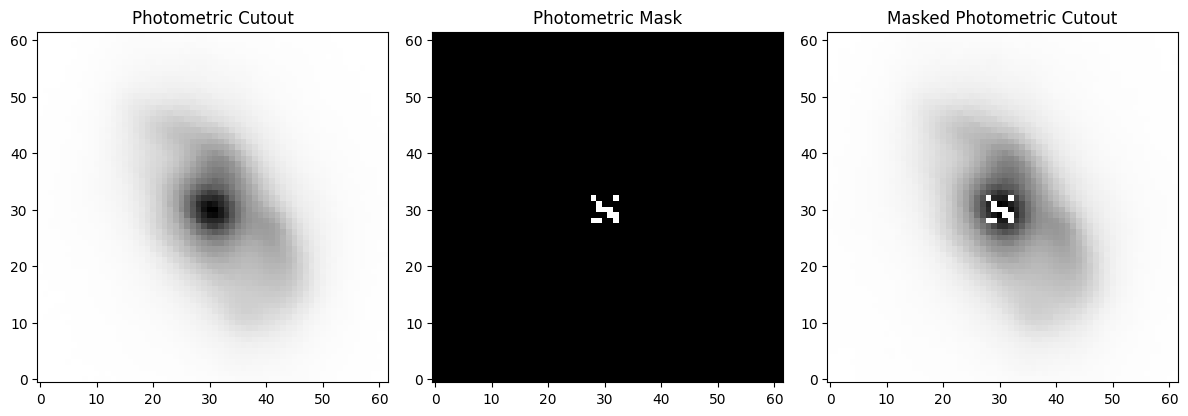

In [ ]:
objid = 1025202
i = np.where(catalog["ID"] == objid)[0][0]
cutout_files = sorted(glob.glob(f"{extract_dir}/emline_2d_{grism_band}_ID{objid}_*_*coadd_simple.fits"))
obj_pos = SkyCoord(catalog["RA"][i], catalog["DEC"][i], unit="deg")

### 1. Photometric Image Cutout
image, error = get_image_cutout(
    image_mosaic["SCI"].data, image_mosaic["ERR"].data,
    obj_pos, image_cutout_size, mosaic_wcs
)

# Estimate background RMS from a BKG_CUTOUT_FACTOR-times larger cutout
large_img, _ = get_image_cutout(
    image_mosaic["SCI"].data, image_mosaic["ERR"].data,
    obj_pos, image_cutout_size * BKG_CUTOUT_FACTOR, mosaic_wcs
)
_sc = SigmaClip(sigma=3.0)
_bkgrms_est = StdBackgroundRMS(_sc)
if large_img is not None and not np.allclose(large_img.data, 0.0):
    photo_bkg_std = float(_bkgrms_est.calc_background_rms(large_img.data))
else:
    photo_bkg_std = float(_bkgrms_est.calc_background_rms(image.data))

# Default mask: pixels with positive, finite noise
photo_default_mask = ((error.data > 0) & np.isfinite(error.data)).astype(float)

# Collect F200W / F115W cutouts for multi-band interloper detection.
# Use plain Cutout2D (no error correction) to avoid side-effects on mosaic data.
_extra_photo = []
for _em, _ew in [(image_mosaic_f200w, wcs_f200w), (image_mosaic_f115w, wcs_f115w)]:
    if _em is not None:
        try:
            _ec = Cutout2D(_em[1].data, obj_pos, size=image_cutout_size, wcs=_ew)
            _extra_photo.append(_ec.data.astype(float))
        except Exception:
            pass

photo_mask = build_mask(image.data, bkg_std=photo_bkg_std, clip_sigma=3.0,
                        interloper_threshold=3.0, hot_pixel_threshold=50.0,
                        hot_pixel_maxiter=1, input_mask=photo_default_mask,
                        margin_pixels=0,
                        extra_images=_extra_photo if _extra_photo else None)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image.data, origin='lower', cmap='gray_r')
axes[0].set_title("Photometric Cutout")
axes[1].imshow(photo_mask, origin='lower', cmap='gray_r')
axes[1].set_title("Photometric Mask")
axes[2].imshow(image.data * photo_mask, origin='lower', cmap='gray_r')
axes[2].set_title("Masked Photometric Cutout")
plt.tight_layout()
plt.show()

In [17]:
hdul = fits.open(f"/xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID{objid}.fits")
hdul.info()

Filename: /xdisk/timeifler/jiachuanxu/jwst/congress/data_compile/data_compile_GDN_ID1025202.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      89   ()      
  1  BrB_AR        1 ImageHDU        33   (31, 31)   float32   
  2  BrB_ARN       1 ImageHDU        10   (31, 31)   float32   
  3  BrB_ARP       1 ImageHDU        26   (124, 124)   float32   
  4  BRB_ARM       1 ImageHDU        12   (31, 31)   float32   
  5  BrB_BR        1 ImageHDU        33   (31, 31)   float32   
  6  BrB_BRN       1 ImageHDU        10   (31, 31)   float32   
  7  BrB_BRP       1 ImageHDU        26   (124, 124)   float32   
  8  BRB_BRM       1 ImageHDU        12   (31, 31)   float32   
  9  F444WIMG      1 ImageHDU        35   (62, 62)   float32   
 10  F444WERR      1 ImageHDU        11   (62, 62)   float32   
 11  F444WPSF      1 ImageHDU        23   (256, 256)   float64   
 12  F444WMSK      1 ImageHDU        12   (62, 62)   float64   


In [22]:
PA1 = hdul["BrB_AR"].header["FRAME_PA"]/np.pi*180
PA2 = hdul["BrB_BR"].header["FRAME_PA"]/np.pi*180

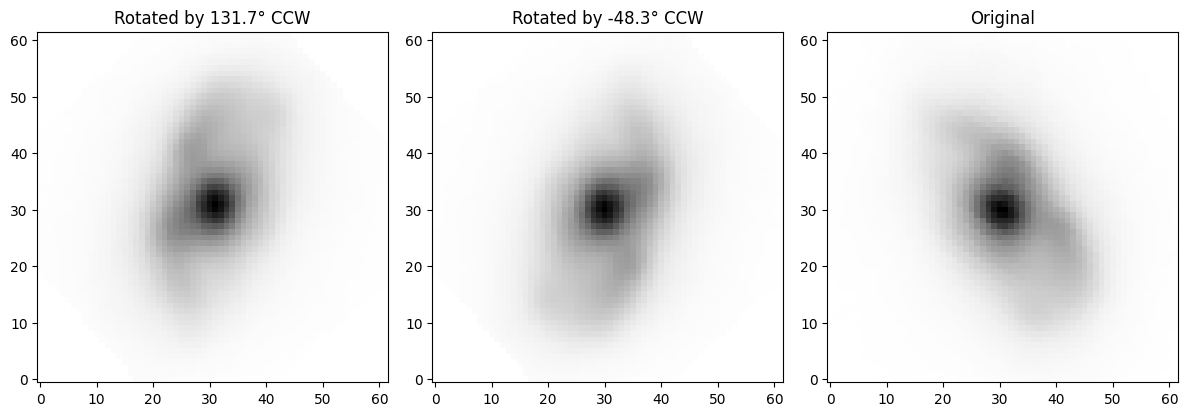

In [30]:
rot_1 = ndimage_rotate(image.data, PA1, reshape=False, order=3)
rot_2 = ndimage_rotate(image.data, PA2, reshape=False, order=3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rot_1, origin='lower', cmap='gray_r')
axes[0].set_title(f"Rotated by {-PA1:.1f}° CCW")
axes[1].imshow(rot_2, origin='lower', cmap='gray_r')
axes[1].set_title(f"Rotated by {-PA2:.1f}° CCW")
axes[2].set_title("Original")
axes[2].imshow(image.data, origin='lower', cmap='gray_r')
plt.tight_layout()
plt.show()

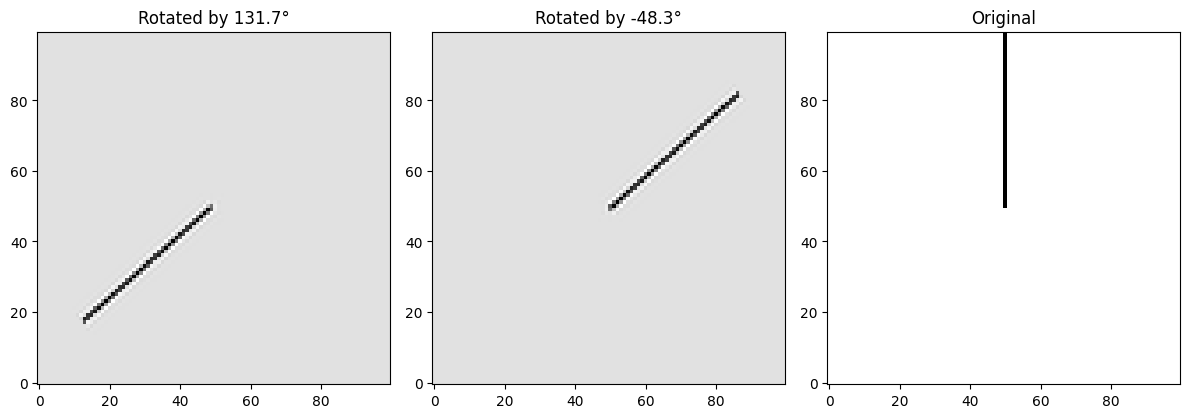

In [28]:
test_image = np.zeros((100, 100))
test_image[50:100, 50] = 1
rot_1 = ndimage_rotate(test_image, PA1, reshape=False, order=3)
rot_2 = ndimage_rotate(test_image, PA2, reshape=False, order=3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rot_1, origin='lower', cmap='gray_r')
axes[0].set_title(f"Rotated by {-PA1:.1f}°")
axes[1].imshow(rot_2, origin='lower', cmap='gray_r')
axes[1].set_title(f"Rotated by {-PA2:.1f}°")
axes[2].set_title("Original")
axes[2].imshow(test_image, origin='lower', cmap='gray_r')
plt.tight_layout()
plt.show()